MATCHES DATA
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0 

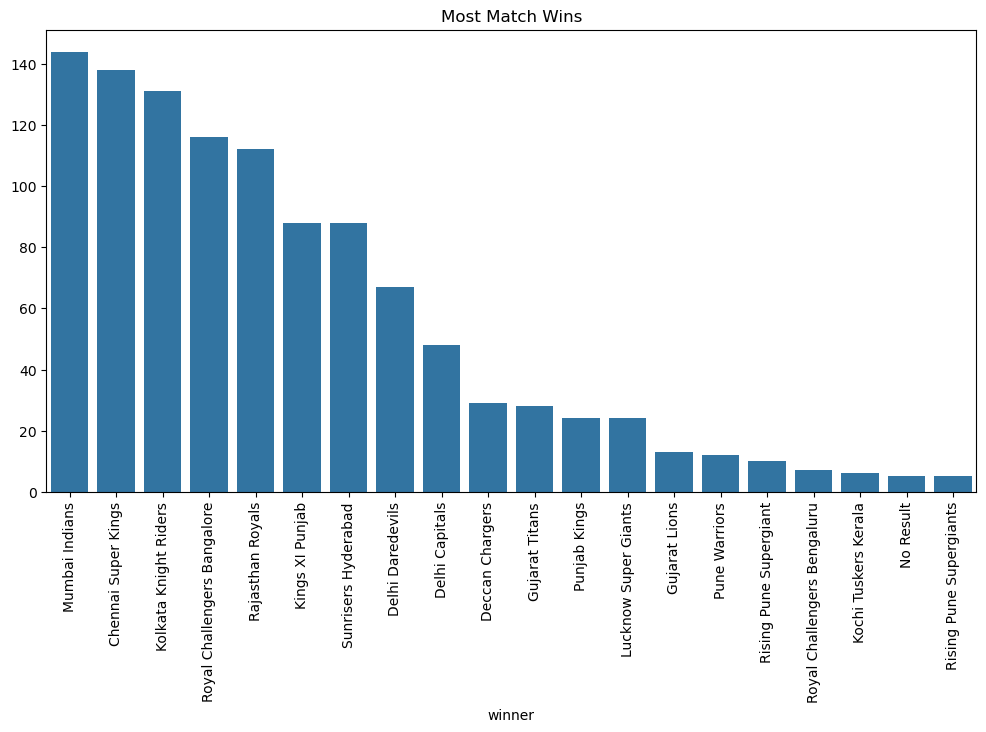

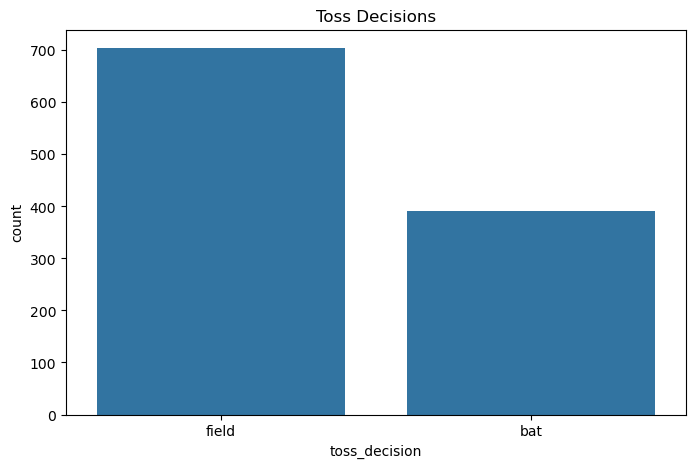

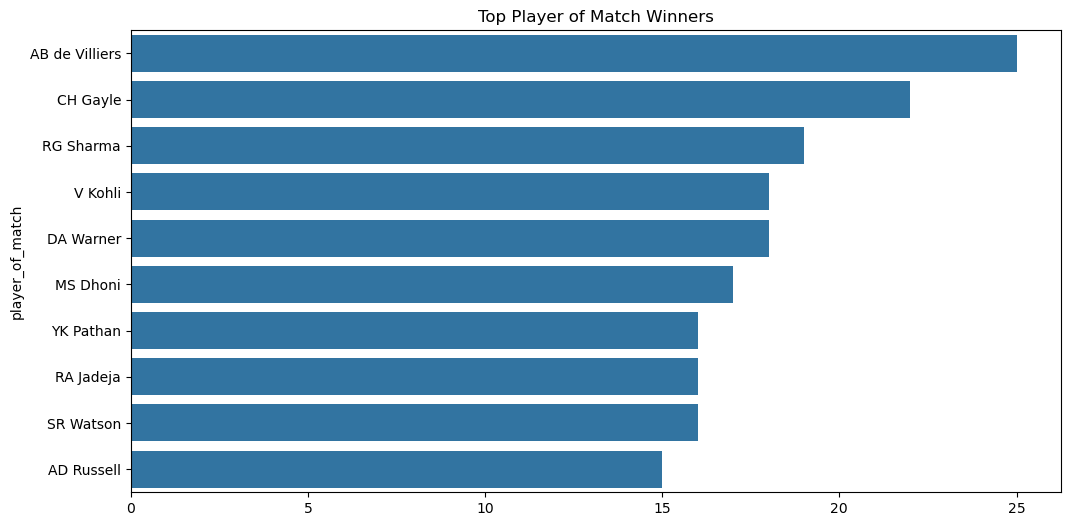

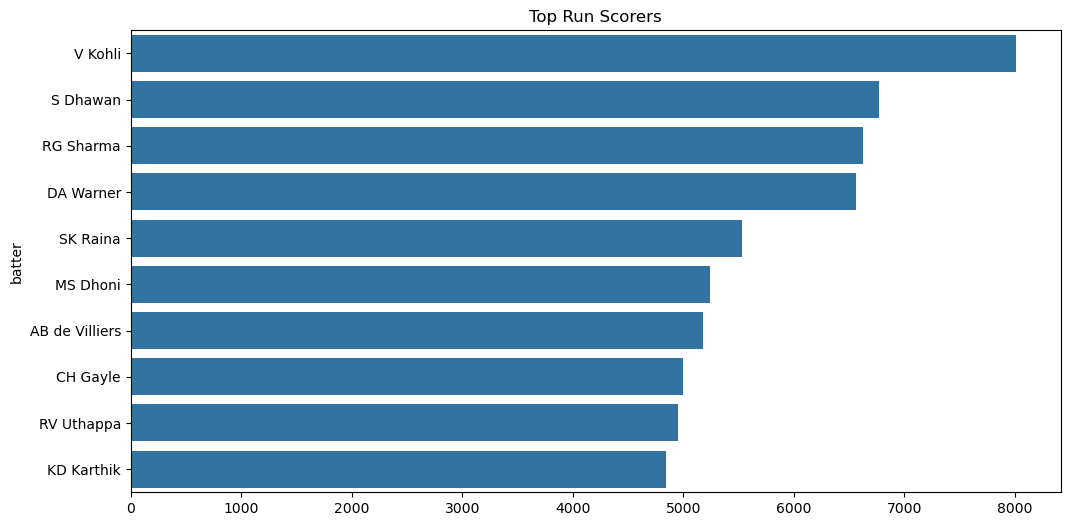

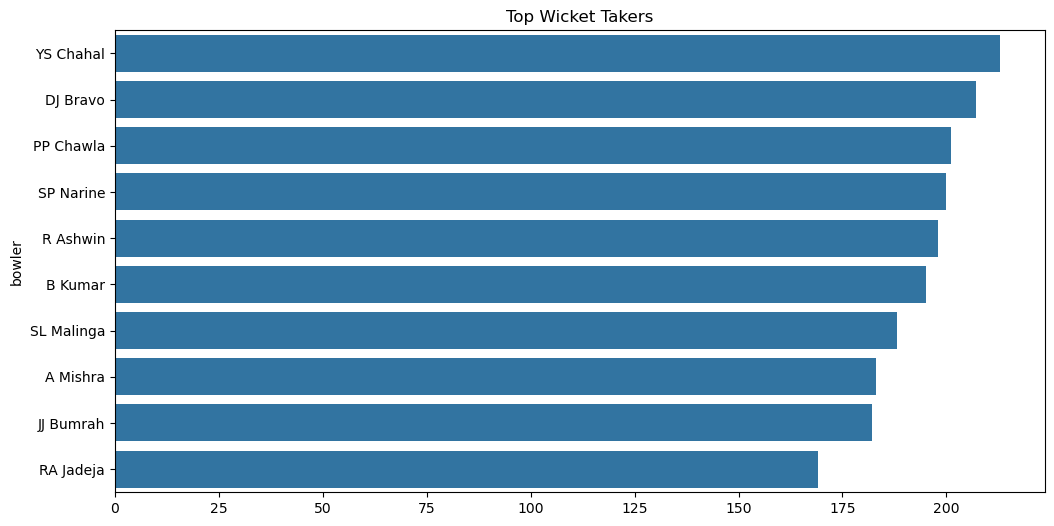

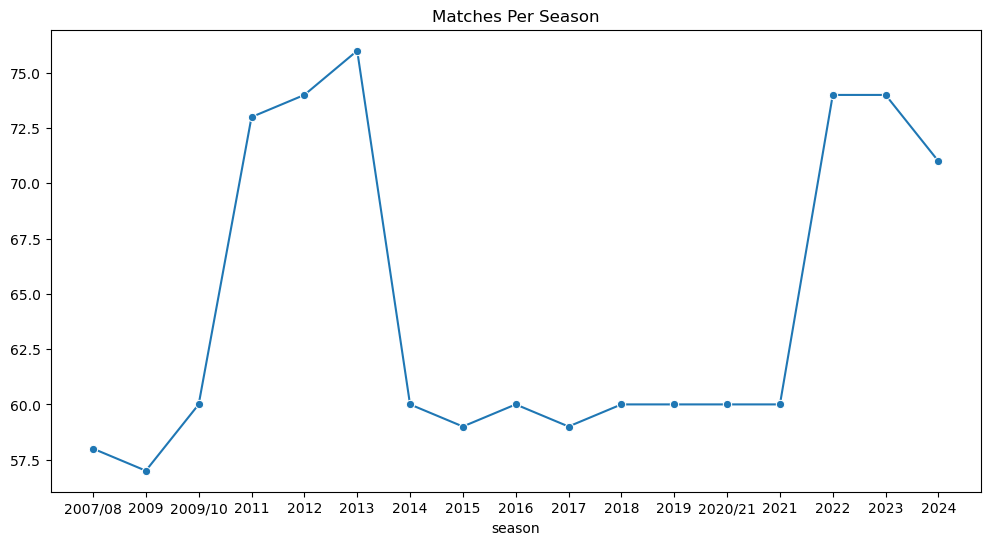

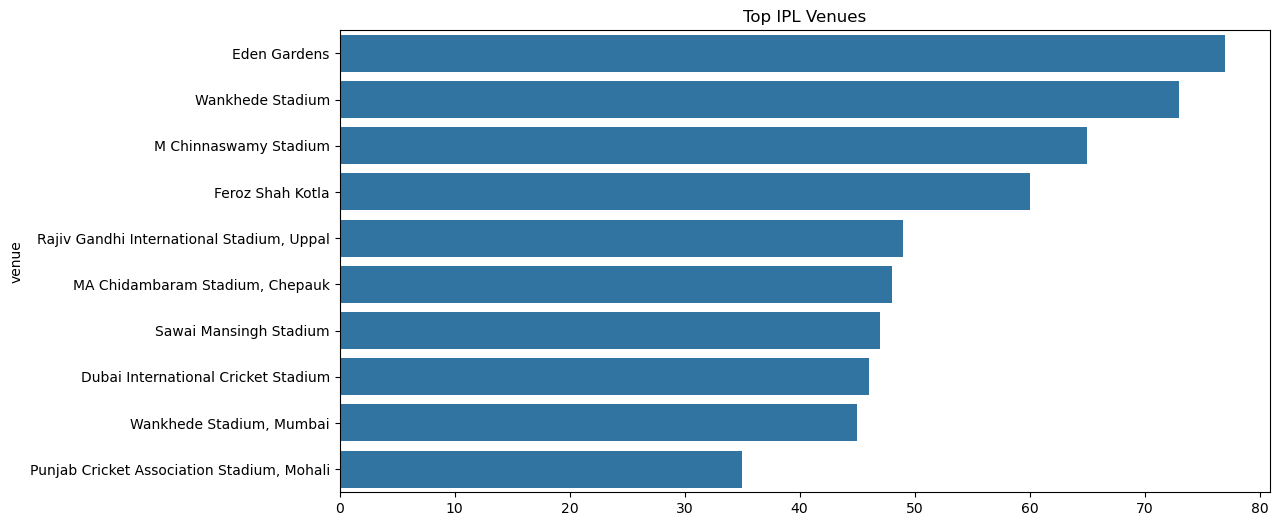

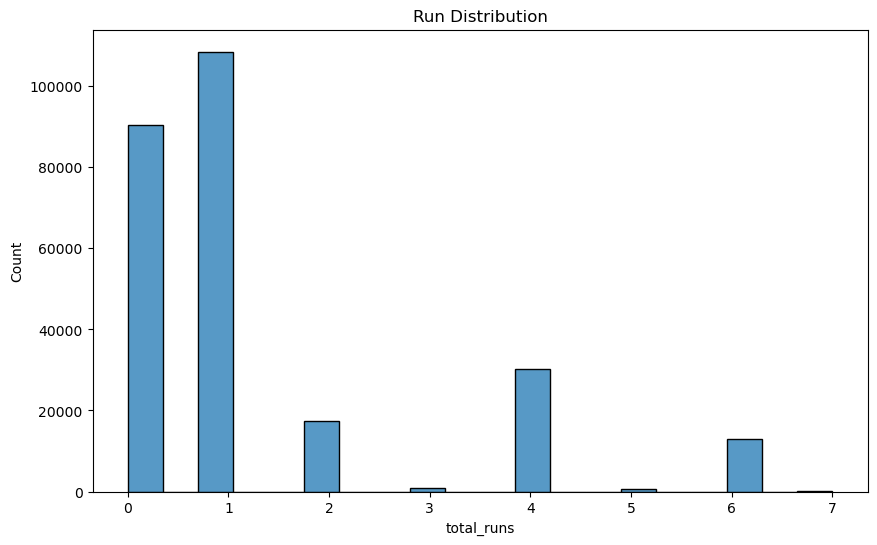

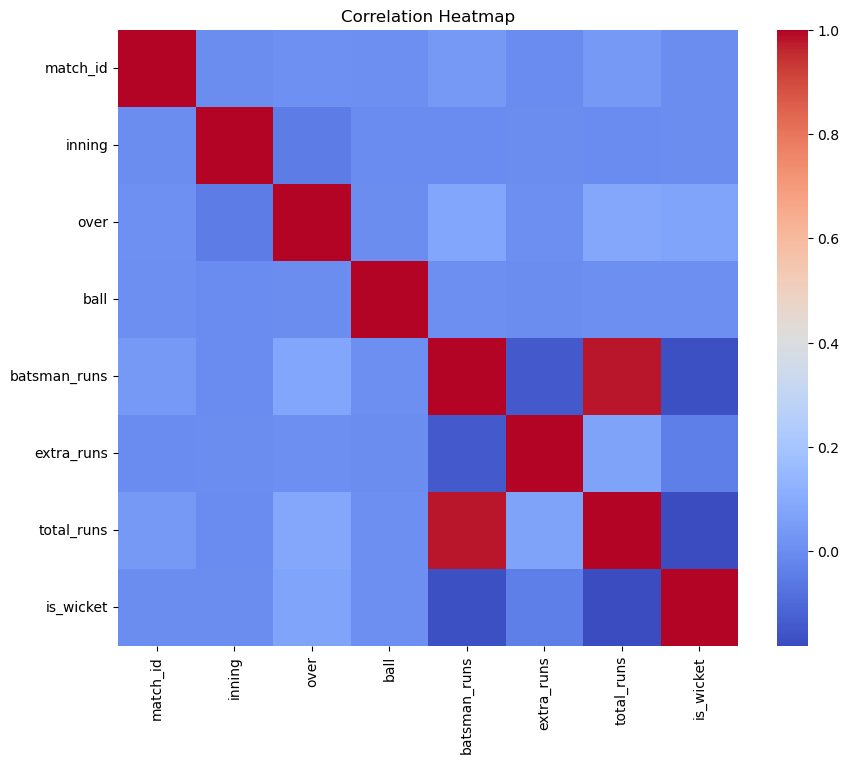

In [1]:
# ==========================================
# IPL EDA PROJECT
# ==========================================

# ------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------

import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CREATE FOLDERS
# ==========================================

os.makedirs(
    "../../../datasets/cleaned/ipl",
    exist_ok=True
)

# ==========================================
# LOAD DATASETS
# ==========================================

matches = pd.read_csv(
    "../../../datasets/raw/ipl/matches.csv"
)

deliveries = pd.read_csv(
    "../../../datasets/raw/ipl/deliveries.csv"
)

print("MATCHES DATA")
print(matches.head())

print("\nDELIVERIES DATA")
print(deliveries.head())

# ==========================================
# BASIC INFO
# ==========================================

print("\nMATCHES SHAPE")
print(matches.shape)

print("\nDELIVERIES SHAPE")
print(deliveries.shape)

print("\nMISSING VALUES")
print(matches.isnull().sum())

# ==========================================
# CLEANING
# ==========================================

matches = matches.drop_duplicates()

deliveries = deliveries.drop_duplicates()

matches["winner"] = matches["winner"].fillna(
    "No Result"
)

# ==========================================
# SAVE CLEANED DATASETS
# ==========================================

matches.to_csv(
    "../../../datasets/cleaned/ipl/cleaned_matches.csv",
    index=False
)

deliveries.to_csv(
    "../../../datasets/cleaned/ipl/cleaned_deliveries.csv",
    index=False
)

# ==========================================
# MOST MATCH WINS
# ==========================================

wins = matches["winner"].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=wins.index,
    y=wins.values
)

plt.xticks(rotation=90)

plt.title("Most Match Wins")

plt.show()

# ==========================================
# TOSS DECISIONS
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    x=matches["toss_decision"]
)

plt.title("Toss Decisions")

plt.show()

# ==========================================
# TOP PLAYER OF MATCH
# ==========================================

top_players = matches[
    "player_of_match"
].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_players.values,
    y=top_players.index
)

plt.title("Top Player of Match Winners")

plt.show()

# ==========================================
# TOP RUN SCORERS
# ==========================================

top_batsmen = deliveries.groupby(
    "batter"
)["batsman_runs"].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_batsmen.values,
    y=top_batsmen.index
)

plt.title("Top Run Scorers")

plt.show()

# ==========================================
# TOP WICKET TAKERS
# ==========================================

wickets = deliveries[
    deliveries["is_wicket"] == 1
]

top_bowlers = wickets[
    "bowler"
].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_bowlers.values,
    y=top_bowlers.index
)

plt.title("Top Wicket Takers")

plt.show()

# ==========================================
# MATCHES PER SEASON
# ==========================================

season_matches = matches[
    "season"
].value_counts().sort_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=season_matches.index,
    y=season_matches.values,
    marker="o"
)

plt.title("Matches Per Season")

plt.show()

# ==========================================
# MOST USED VENUES
# ==========================================

venues = matches[
    "venue"
].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=venues.values,
    y=venues.index
)

plt.title("Top IPL Venues")

plt.show()

# ==========================================
# RUN DISTRIBUTION
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    deliveries["total_runs"],
    bins=20
)

plt.title("Run Distribution")

plt.show()

# ==========================================
# CORRELATION HEATMAP
# ==========================================

numeric_data = deliveries.select_dtypes(
    include=["int64", "float64"]
)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_data.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================
# END
# ==========================================